In [2]:
from src.planar_preferential_attachment_graph import PlanarPreferentialAttachmentGraph, FitnessType, EdgeRemovalStrategy
from src.drawer import Drawer

In [ ]:
import os
import json
import itertools
import networkx as nx
from concurrent.futures import ProcessPoolExecutor, as_completed
import experiments.planar_pa_generation_worker as worker

os.makedirs(RESULTS_DIR, exist_ok=True)

# Build task list
all_tasks = []
for n, m, fitness, strategy, rep in itertools.product(
    N_VALUES, M_VALUES, FITNESS_FUNCTIONS, STRATEGIES, range(REP_START, REP_END)
):
    all_tasks.append({
        "n": n,
        "m": m,
        "fitness_type": fitness["type"],
        "fitness_alpha": fitness["alpha"],
        "strategy": strategy,
        "rep": rep,
    })

# Filter out already done tasks using the worker helper
tasks = [t for t in all_tasks if not worker.is_already_done(t, RESULTS_DIR)]
already_done = len(all_tasks) - len(tasks)

print(f"Rep range: [{REP_START}, {REP_END})")
print(f"Total tasks for this machine: {len(all_tasks)}")
print(f"Already completed: {already_done}")
print(f"Remaining: {len(tasks)}")
print(f"Results directory: {RESULTS_DIR}")

if not tasks:
    print("\nAll tasks already completed!")
else:
    all_results = []
    num_workers = min(6, os.cpu_count() or 1)

    print(f"Running with ProcessPoolExecutor ({num_workers} workers)...\n")
    with ProcessPoolExecutor(max_workers=num_workers) as executor:
        # Submit the worker.generate_single callable so it is importable in child processes
        futures = {executor.submit(worker.generate_single, task, RESULTS_DIR): task for task in tasks}

        for i, future in enumerate(as_completed(futures), 1):
            task = futures[future]
            try:
                result = future.result()
                all_results.append(result)
                summary = result["summary"]
                print(
                    f"[{i}/{len(tasks)}] ",
                    f"n={task['n']} m={task['m']} ",
                    f"{task['fitness_type'].name}(α={task['fitness_alpha']}) ",
                    f"{task['strategy'].name} rep{task['rep']}: ",
                    f"edges={summary['num_edges']}, ",
                    f"removed={summary['total_edges_removed']}, ",
                    f"non-planar={summary['non_planar_steps']}"
                )
            except Exception as e:
                print(f"[{i}/{len(tasks)}] FAILED: {task} -> {e}")

    print(f"\nDone! {len(all_results)}/{len(tasks)} succeeded.")
    print(f"Total completed: {already_done + len(all_results)}/{len(all_tasks)}")
    print(f"Results saved to: {RESULTS_DIR}/")


Number of nodes: 50
Number of edges: 85
Average degree: 3.40

Step Statistics:
  Total edges added: 144
  Total edges removed: 59
  Non-planar steps: 38


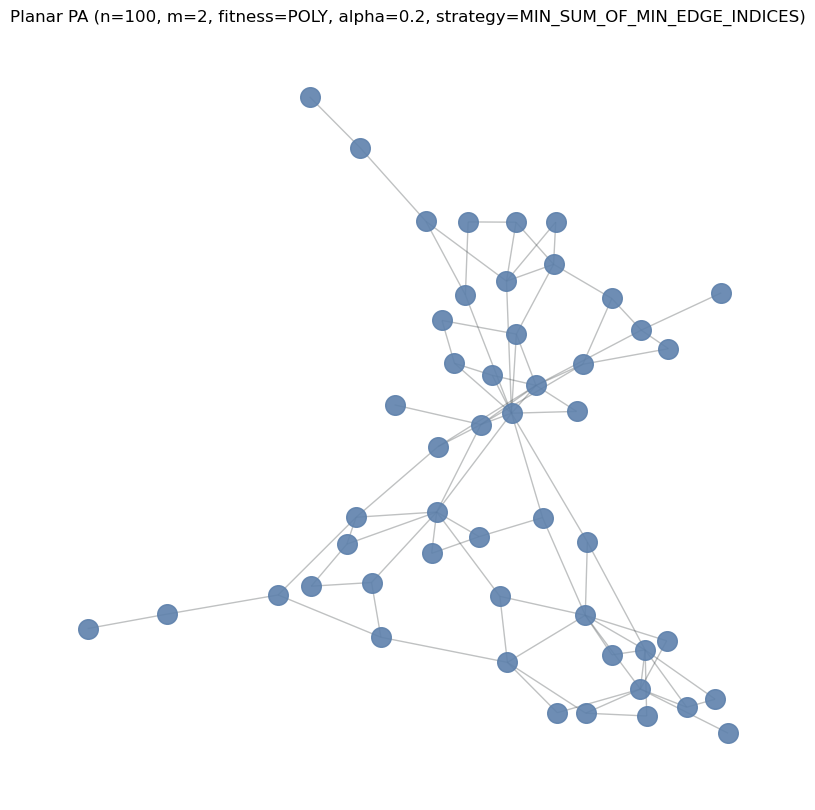

In [6]:
G = PlanarPreferentialAttachmentGraph(n=50, m=3, fitness=FitnessType.POLY, fitness_alpha=0.2, strategy=EdgeRemovalStrategy.MAX_SUM_OF_MAX_EDGE_INDICES, track_history=True)

print(f"Number of nodes: {G.number_of_nodes()}"
      f"\nNumber of edges: {G.number_of_edges()}"
      f"\nAverage degree: {sum(dict(G.degree()).values()) / G.number_of_nodes():.2f}")

# Print step history
if G.step_info:
    total_added = sum(s.edges_added for s in G.step_info)
    total_removed = sum(s.edges_removed for s in G.step_info)
    non_planar_steps = sum(1 for s in G.step_info if not s.was_planar_before_removal)
    
    print(f"\nStep Statistics:")
    print(f"  Total edges added: {total_added}")
    print(f"  Total edges removed: {total_removed}")
    print(f"  Non-planar steps: {non_planar_steps}")

drawer = Drawer()
drawer.draw_graph(G, title="Planar PA (n=100, m=2, fitness=POLY, alpha=0.2, strategy=MIN_SUM_OF_MIN_EDGE_INDICES)")